In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/eceo-epfl/coralscapesScripts.git
%cd coralscapesScripts
!pip install -e .
!pip install segmentation-models-pytorch \
             transformers \
             peft \
             torchmetrics \
             monai \
             albumentations \
             tqdm \
             ftfy \
             regex \
             huggingface_hub \
             pyyaml \
             scikit-learn \
             matplotlib

fatal: destination path 'coralscapesScripts' already exists and is not an empty directory.
/content/coralscapesScripts
Obtaining file:///content/coralscapesScripts
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for coralscapes (pyproject.toml) ... done
  Created wheel for coralscapes: filename=coralscapes-0.1.0-0.editable-py3-none-any.whl size=2855 sha256=4c24f259f447c1ae4fd3620694ede885b964d7e9a3f078d8732456d0eb1612c2
  Stored in directory: /tmp/pip-ephem-wheel-cache-9f6x9e95/wheels/a7/94/2e/a7f1718b5df49f04f164df1a2832c7cda6e05dc5fa04e4d17e
Successfully built coralscapes
  Attempting uninstall: coralscapes
    Found existing installation: coralscapes 0.1.0
    Uninstalling coralscapes-0.1.0:
      Successfully uninstalled coralscapes-0.1.0


# Setup

In [3]:
import torch

import albumentations as A

from torch.utils.data import DataLoader
from coralscapesScripts.datasets.dataset import Coralscapes
from coralscapesScripts.datasets.preprocess import get_preprocessor
from coralscapesScripts.datasets.utils import calculate_weights

from coralscapesScripts.segmentation.model import Benchmark_Run
from coralscapesScripts.segmentation.benchmarking import launch_benchmark

from coralscapesScripts.visualization import show_samples

from coralscapesScripts.logger import Logger, save_benchmark_run
from coralscapesScripts.io import setup_config, get_parser, update_config_with_args
import copy

In [4]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [5]:
device_count = torch.cuda.device_count()
for i in range(device_count):
    print(f"CUDA Device {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

CUDA Device 0: Tesla T4


device(type='cuda')

## Config

In [6]:
import os
os.chdir('/content/coralscapesScripts/nbs')

In [7]:
cfg = setup_config(config_path='../configs/deeplabv3+resnet50.yaml', config_base_path='../configs/base.yaml')
#cfg = setup_config(config_path='../configs/segformer-mit-b2.yaml', config_base_path='../configs/base.yaml')
# cfg = setup_config(config_path='../configs/dpt-dinov2-base_lora.yaml', config_base_path='../configs/base.yaml')

## Args

In [8]:
args_input = "--batch-size=2 --batch-size-eval=2"
args_input = args_input.split(" ")

parser = get_parser()
args = parser.parse_args(args_input)

cfg = update_config_with_args(cfg, args)
cfg

{'run_name': 'deeplabv3+resnet50_run',
 'logger': {'wandb_project': 'coralscapes', 'log_epochs': 5},
 'data': {'root': '../../coralscapes',
  'batch_size': 2,
  'batch_size_eval': 2,
  'weight': False},
 'augmentation': {'train': {'RandomScale': {'scale_limit': [-0.25, 1]},
   'RandomCrop': {'width': 768, 'height': 768},
   'HorizontalFlip': {'p': 0.5},
   'Normalize': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}},
  'val': {'Normalize': {'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225]}},
  'test': {'Normalize': {'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225]}}},
 'model': {'name': 'deeplabv3+resnet50'},
 'training': {'epochs': 1000,
  'optimizer': {'type': 'torch.optim.SGD',
   'lr': 0.001,
   'weight_decay': 0.0001,
   'momentum': 0.9},
  'scheduler': {'type': 'torch.optim.lr_scheduler.PolynomialLR',
   'power': 0.9,
   'total_iters': 1000},
  'loss': {'type': 'cross_entropy', 'reduction': 'mean'}}}

# Data

In [9]:
transforms = {}
for split in cfg.augmentation:
    transforms[split] = A.Compose(
        [
            getattr(A, transform_name)(**transform_params) for transform_name, transform_params
                                                                 in cfg.augmentation[split].items()
        ]
    )

In [10]:
#!apt-get install p7zip-full -y
#%cd /content
#!mkdir -p coralscapes
#!wget -O coralscapes.7z "https://zenodo.org/records/15061505/files/coralscapes.7z?download=1"
#!7z x coralscapes.7z -o/content/coralscapes -y

In [11]:
!mv /content/coralscapes/coralscapes/* /content/coralscapes/
!rmdir /content/coralscapes/coralscapes

mv: cannot stat '/content/coralscapes/coralscapes/*': No such file or directory
rmdir: failed to remove '/content/coralscapes/coralscapes': No such file or directory


In [12]:
import os
print(os.path.exists("/content/coralscapes/classes.json"))

False


In [13]:
#Run only to send database to drive
#from google.colab import drive
#drive.mount('/content/drive')

#!mkdir -p /content/drive/MyDrive/Coralscapes_Data
#!cp -r /content/coralscapes/* /content/drive/MyDrive/Coralscapes_Data/

In [14]:
cfg.data.root = '/content/drive/MyDrive/Coralscapes_Data'

train_dataset = Coralscapes(root = cfg.data.root, split = 'train', transform = transforms["train"])
transform_target = cfg.training.eval.transform_target if cfg.training.eval is not None and cfg.training.eval.transform_target is not None else True
val_dataset = Coralscapes(root = cfg.data.root, split = 'val', transform = transforms["val"], transform_target=transform_target)
test_dataset = Coralscapes(root = cfg.data.root, split = 'test', transform = transforms["test"], transform_target=transform_target)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=cfg.data.batch_size, shuffle=True, num_workers=4, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.data.batch_size_eval, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=cfg.data.batch_size_eval, shuffle=False, num_workers=4)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [16]:
print(len(train_loader), len(val_loader), len(test_loader))

758 83 196


In [17]:
weight = calculate_weights(train_dataset).to(device) if(cfg.data.weight) else None

## Visualizations

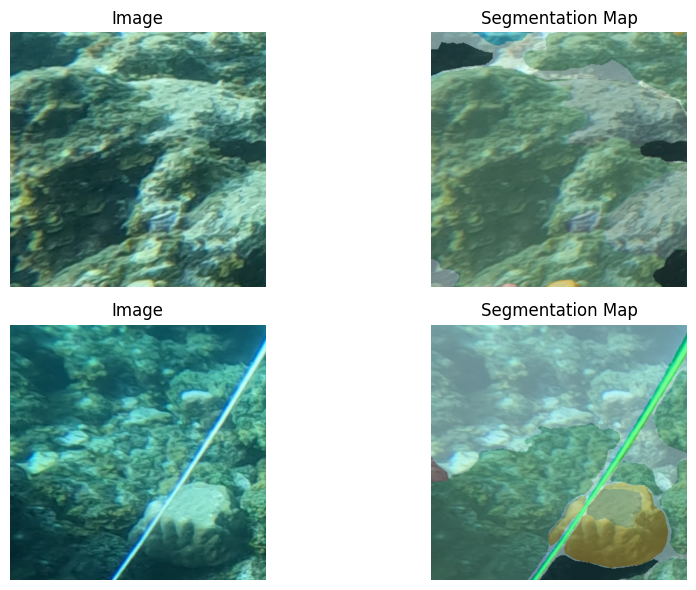

In [18]:
show_samples(train_dataset, n=2)

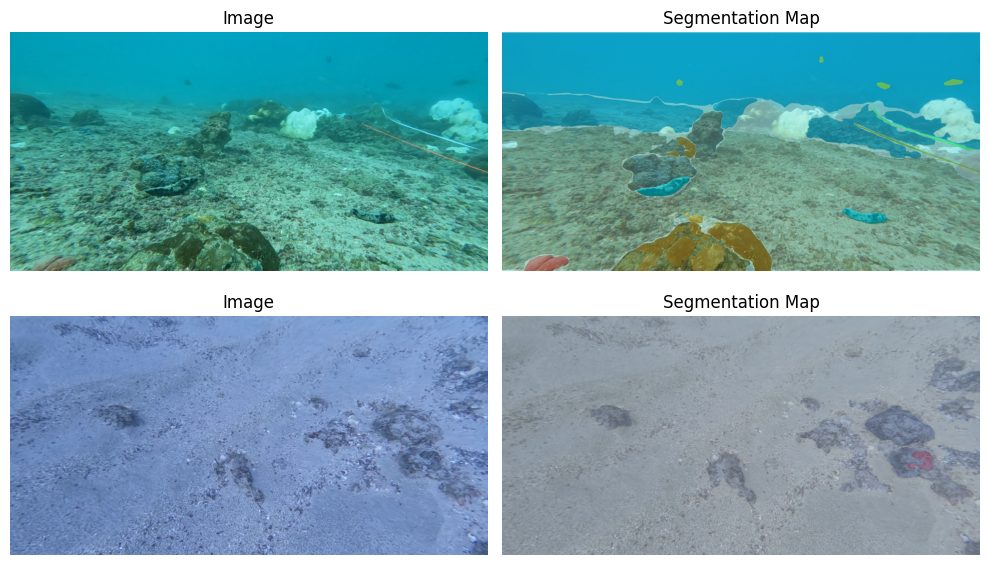

In [19]:
show_samples(val_dataset, n=2)

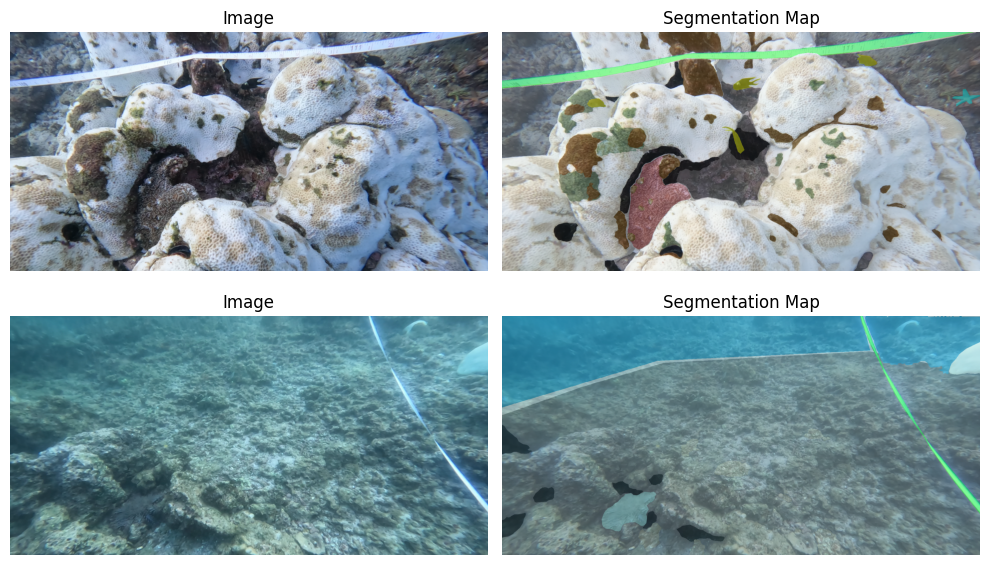

In [20]:
show_samples(test_dataset, n=2)

# Benchmarking

## Model

In [21]:
#Needed for benchmark
!pip install --prefer-binary "huggingface_hub>=0.23.0,<0.26.0" "transformers>=4.40.0"

In [22]:
#!mkdir -p /content/coralscapesScripts/nbs/model_checkpoints
#!mkdir -p /content/drive/MyDrive/Coralscapes_Checkpoints

#!wget -O model_checkpoints.7z "https://zenodo.org/records/15061505/files/model_checkpoints.7z?download=1"

#!7z x model_checkpoints.7z -o/content/coralscapesScripts/nbs/ -y

#!cp -r /content/coralscapesScripts/nbs/model_checkpoints/* /content/drive/MyDrive/Coralscapes_Checkpoints/

In [23]:
# 1. Monta Google Drive (se non lo hai già fatto nella sessione corrente)
from google.colab import drive
drive.mount('/content/drive')

# 2. Crea la cartella dei checkpoint su Google Drive
!mkdir -p /content/drive/MyDrive/Coralscapes_Checkpoints

# 3. Copia tutti i checkpoint estratti su Google Drive
!cp -r /content/coralscapesScripts/nbs/model_checkpoints/* /content/drive/MyDrive/Coralscapes_Checkpoints/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/coralscapesScripts/nbs/model_checkpoints/*': No such file or directory


In [24]:
cfg.model.checkpoint = "./model_checkpoints/deeplabv3plus_resnet50_kuma_run1/model_epoch950"
#cfg.model.checkpoint = "./model_checkpoints/segformer_mit_b2_kuma_run1/model_epoch150"

In [33]:
!ls -R /content/drive/MyDrive/Coralscapes_Checkpoints

/content/drive/MyDrive/Coralscapes_Checkpoints:
final_model_checkpoints

/content/drive/MyDrive/Coralscapes_Checkpoints/final_model_checkpoints:
deeplabv3plus_resnet50_epoch700  dpt_dinov2_base_epoch165


In [34]:
# 1. Configurazione per DeepLabV3+ ResNet50
cfg.run_name = 'deeplabv3plus_resnet50'
cfg.model.name = 'deeplabv3+resnet50'
cfg.model.checkpoint = '/content/drive/MyDrive/Coralscapes_Checkpoints/final_model_checkpoints/deeplabv3plus_resnet50_epoch700'

# 2. Inizializzazione del benchmark
benchmark_run = Benchmark_Run(
    run_name = cfg.run_name,
    model_name = cfg.model.name,
    N_classes = train_dataset.N_classes,
    device = device,
    model_kwargs = cfg.model.kwargs,
    model_checkpoint = cfg.model.checkpoint,
    lora_kwargs = cfg.lora,
    training_hyperparameters = cfg.training
)

In [35]:
benchmark_run.print_trainable_parameters()

trainable params: 26687608 || all params: 26687608 || trainable%: 100.00


# Eval

## Base Metrics - Accuracy & mIoU

In [36]:
from coralscapesScripts.segmentation.eval import Evaluator

if hasattr(benchmark_run, "preprocessor"):
    evaluator = Evaluator(N_classes = benchmark_run.N_classes, device = benchmark_run.device, preprocessor = benchmark_run.preprocessor, eval_params=benchmark_run.eval)
else:
    evaluator = Evaluator(N_classes = benchmark_run.N_classes, device = benchmark_run.device, eval_params=benchmark_run.eval)

In [37]:
train_metric_results = evaluator.evaluate_model(train_loader, benchmark_run.model, split = "train")
train_metric_results

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


{'accuracy': 0.9294083714485168, 'mean_iou': 0.8193236589431763}

In [38]:
val_metric_results = evaluator.evaluate_model(val_loader, benchmark_run.model, split = "val")
val_metric_results

{'accuracy': 0.9397358298301697, 'mean_iou': 0.7300883531570435}

In [39]:
test_metric_results = evaluator.evaluate_model(test_loader, benchmark_run.model, split = "test")
test_metric_results

{'accuracy': 0.7814502120018005, 'mean_iou': 0.45542386174201965}

## Other metrics - per class IoU
- https://lightning.ai/docs/torchmetrics/stable/

In [40]:
from torchmetrics.classification import JaccardIndex
import numpy as np

metric_dict = {
            "iou": JaccardIndex(task="multiclass", num_classes=int(benchmark_run.N_classes), ignore_index = 0, average='none').to(device)
            }

if hasattr(benchmark_run, "preprocessor"):
    evaluator = Evaluator(metric_dict = metric_dict, N_classes = benchmark_run.N_classes, device = benchmark_run.device, preprocessor = benchmark_run.preprocessor, eval_params=benchmark_run.eval)
else:
    evaluator = Evaluator(metric_dict = metric_dict, N_classes = benchmark_run.N_classes, device = benchmark_run.device, eval_params=benchmark_run.eval)

In [41]:
test_metric_results = evaluator.evaluate_model(test_loader, benchmark_run.model, split = "test")
test_metric_results["iou"] = {train_dataset.id2label[class_id]:class_iou for class_id, class_iou in enumerate(test_metric_results["iou"])}
test_metric_results

{'iou': {'unlabeled': np.float32(0.0),
  'seagrass': np.float32(0.7867359),
  'trash': np.float32(0.017638264),
  'other coral dead': np.float32(0.021470355),
  'other coral bleached': np.float32(0.7425345),
  'sand': np.float32(0.75598294),
  'other coral alive': np.float32(0.4426741),
  'human': np.float32(0.7195963),
  'transect tools': np.float32(0.45411995),
  'fish': np.float32(0.5324558),
  'algae covered substrate': np.float32(0.5844442),
  'other animal': np.float32(0.12188826),
  'unknown hard substrate': np.float32(0.55222476),
  'background': np.float32(0.7948206),
  'dark': np.float32(0.58768994),
  'transect line': np.float32(0.77346444),
  'massive/meandering bleached': np.float32(0.4664068),
  'massive/meandering alive': np.float32(0.6908765),
  'rubble': np.float32(0.570896),
  'branching bleached': np.float32(0.41221806),
  'branching dead': np.float32(0.423176),
  'millepora': np.float32(0.6855656),
  'branching alive': np.float32(0.21655604),
  'massive/meandering d

In [42]:
np.array(list(test_metric_results["iou"].values()))[1:].mean() #Ensure mean of the class IoUs matches the mIoU (excluding the unlabeled class)

np.float32(0.4554239)

# Inference

In [43]:
import numpy as np
from PIL import Image

from matplotlib import pyplot as plt
from coralscapesScripts.visualization import color_label, color_correctness

from coralscapesScripts.datasets.preprocess import preprocess_inference
from coralscapesScripts.segmentation.model import predict

In [44]:
inference_image_file_path = test_dataset.images[42]
inference_image = np.array(Image.open(inference_image_file_path).convert('RGB'))

inference_image_target = test_dataset.targets[42]
inference_target = np.array(Image.open(inference_image_target))
inference_target_colors = color_label(inference_target)

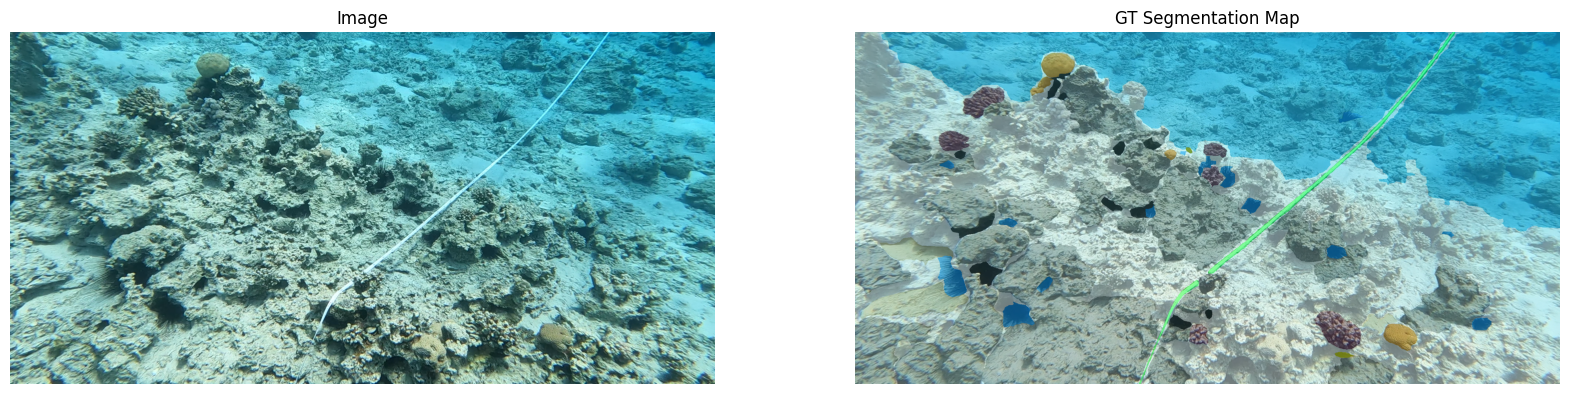

In [45]:
fig, ax = plt.subplots(figsize=(20,5), ncols = 2)
ax[0].imshow(inference_image)
ax[0].set_title("Image")
ax[0].axis("off")
ax[1].imshow(inference_image)
ax[1].imshow(inference_target_colors, alpha = 0.4)
ax[1].set_title("GT Segmentation Map")
ax[1].axis("off")
plt.show()

In [46]:
preprocessed_batch, window_dims = preprocess_inference(inference_image, transforms["test"], benchmark_run)

In [47]:
benchmark_run.model.eval()
with torch.no_grad():
    inference_prediction = predict(preprocessed_batch,
                                    benchmark_run,
                                    window_dims = window_dims)

In [48]:
inference_prediction_colors = color_label(inference_prediction)
inference_correctness = color_correctness(inference_target, inference_prediction)

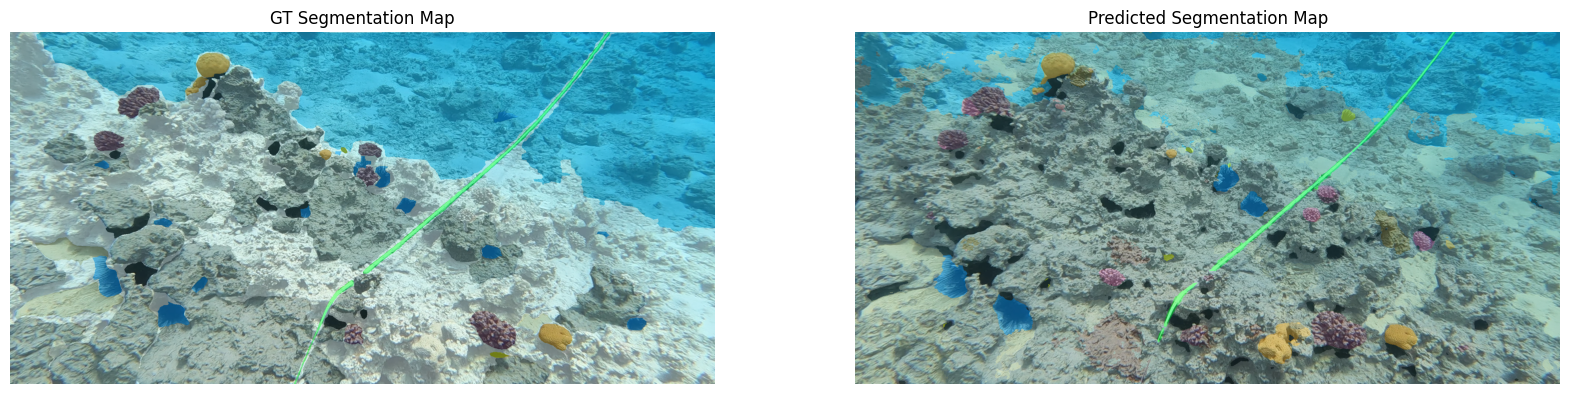

In [49]:
fig, ax = plt.subplots(figsize=(20,5), ncols = 2)
ax[0].imshow(inference_image)
ax[0].imshow(inference_target_colors, alpha = 0.4)
ax[0].set_title("GT Segmentation Map")
ax[0].axis("off")
ax[1].imshow(inference_image)
ax[1].imshow(inference_prediction_colors, alpha = 0.4)
ax[1].set_title("Predicted Segmentation Map")
ax[1].axis("off")
plt.show()

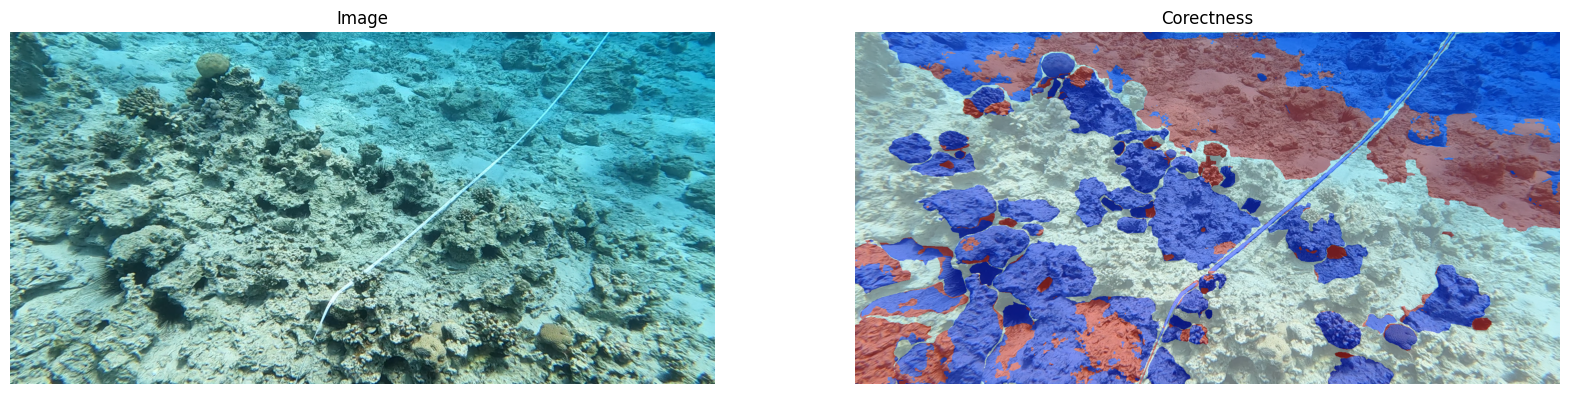

In [50]:
fig, ax = plt.subplots(figsize=(20,5), ncols = 2)
ax[0].imshow(inference_image)
ax[0].set_title("Image")
ax[0].axis("off")
ax[1].imshow(inference_image)
ax[1].imshow(inference_correctness, alpha = 0.4)
ax[1].set_title("Corectness")
ax[1].axis("off")
plt.show()